In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import seaborn as sns
from datetime import datetime

In [75]:
import sqlite3
from sqlite3 import Connection

# Create in-memory database
conn = sqlite3.connect(':memory:')

In [76]:
with open('/home/user/Downloads/210725_Confidential_YAKWETU platform usage data/working_db_content.sql', 'r') as f:
    sql_dump = f.read()

# Remove MySQL-specific syntax
cleaned_sql = sql_dump.replace('ENGINE=InnoDB', '').replace('CHARSET=utf8mb4', '')

In [77]:


# Import sqlparse
import sqlparse

# Remove MySQL-specific syntax
cleaned_sql = (
    sql_dump.replace('ENGINE=InnoDB', '')
            .replace('CHARSET=utf8mb4', '')
            .replace('AUTO_INCREMENT', '')  # Remove AUTO_INCREMENT keyword
            .replace('`', '')  # Remove backticks
            .replace('COLLATE', '')  # Remove COLLATE keyword
            .replace('DEFAULT', '')  # Remove DEFAULT keyword
			.replace('CHARACTER SET utf8mb4', '')  # Remove CHARACTER SET
			.replace('COLLATE utf8mb4_0900_ai_ci', '')  # Remove COLLATE
			.replace('AUTO_INCREMENT', '')  # Remove AUTO_INCREMENT
			.replace('`', '')  # Remove backticks
)





In [78]:
print(cleaned_sql)

-- MySQL dump 10.13  Distrib 8.0.42, for Win64 (x86_64)
--
-- Host: 139.162.148.75    Database: working_db
-- ------------------------------------------------------
-- Server version	8.0.19-0ubuntu5

/*!40101 SET @OLD_CHARACTER_SET_CLIENT=@@CHARACTER_SET_CLIENT */;
/*!40101 SET @OLD_CHARACTER_SET_RESULTS=@@CHARACTER_SET_RESULTS */;
/*!40101 SET @OLD_COLLATION_CONNECTION=@@COLLATION_CONNECTION */;
/*!50503 SET NAMES utf8 */;
/*!40103 SET @OLD_TIME_ZONE=@@TIME_ZONE */;
/*!40103 SET TIME_ZONE='+00:00' */;
/*!40014 SET @OLD_UNIQUE_CHECKS=@@UNIQUE_CHECKS, UNIQUE_CHECKS=0 */;
/*!40014 SET @OLD_FOREIGN_KEY_CHECKS=@@FOREIGN_KEY_CHECKS, FOREIGN_KEY_CHECKS=0 */;
/*!40101 SET @OLD_SQL_MODE=@@SQL_MODE, SQL_MODE='NO_AUTO_VALUE_ON_ZERO' */;
/*!40111 SET @OLD_SQL_NOTES=@@SQL_NOTES, SQL_NOTES=0 */;

--
-- Table structure for table content
--

DROP TABLE IF EXISTS content;
/*!40101 SET @saved_cs_client     = @@character_set_client */;
/*!50503 SET character_set_client = utf8mb4 */;
CREATE TABLE content

In [79]:
cleaned_sql = """
-- Drop the table if it exists
DROP TABLE IF EXISTS content;

-- Create the content table
CREATE TABLE content (
    content_id INTEGER,
    title TEXT,
    genres TEXT,
    duration INTEGER,
    countries TEXT
);

-- Insert data into the content table
INSERT INTO content (content_id, title, genres, duration, countries) VALUES
(1, 'NAIROBI HALF LIFE', '["Action","Adventure","Crime","Drama","Happy Holidays!","Kenyan Favourites","Suspense","Trending"]', 96, '"KE"'),
(2, 'KATUTURA', '["60% Off this 60th Africa Day 2023","Action","Crime","Drama","Movies for Africa Day!","Suspense"]', 101, '"NA"'),
(3, 'SOUL BOY', '["Adventure","Drama","Family","Family Screen Time","For Kids!","Kenyan Favourites","Supernatural","Suspense","Thriller","Trending"]', 61, '"KE"'),
(4, 'KATI KATI', '["Chick Flick","Drama","Kenyan Favourites","Supernatural","Suspense","Thriller","Trending"]', 75, '"KE"'),
(5, 'SOMETHING NECESSARY', '["Crime","Drama","Kenyan Favourites","Local Language","Movies for Madaraka Day!","Movies from Rift Valley","Movies of Courage","Movies to Watch this International Women''s Month!","Trending"]', 81, '"KE"');
"""

In [80]:
import sqlite3

# Connect to SQLite database 
conn = sqlite3.connect('database.db')
cursor = conn.cursor()

# Execute the cleaned SQL
try:
    cursor.executescript(cleaned_sql)
    conn.commit()
    print("Table created and data inserted successfully.")
except sqlite3.OperationalError as e:
    print(f"SQL Error: {e}")
except Exception as e:
    print(f"Unexpected Error: {e}")
finally:
    cursor.close()

Table created and data inserted successfully.


In [81]:
cursor = conn.cursor()
try:
    cursor.execute("SELECT * FROM content LIMIT 5")
    rows = cursor.fetchall()
    for row in rows:
        print(row)
except sqlite3.OperationalError as e:
    print(f"Query Error: {e}")
finally:
    cursor.close()

(1, 'NAIROBI HALF LIFE', '["Action","Adventure","Crime","Drama","Happy Holidays!","Kenyan Favourites","Suspense","Trending"]', 96, '"KE"')
(2, 'KATUTURA', '["60% Off this 60th Africa Day 2023","Action","Crime","Drama","Movies for Africa Day!","Suspense"]', 101, '"NA"')
(3, 'SOUL BOY', '["Adventure","Drama","Family","Family Screen Time","For Kids!","Kenyan Favourites","Supernatural","Suspense","Thriller","Trending"]', 61, '"KE"')
(4, 'KATI KATI', '["Chick Flick","Drama","Kenyan Favourites","Supernatural","Suspense","Thriller","Trending"]', 75, '"KE"')
(5, 'SOMETHING NECESSARY', '["Crime","Drama","Kenyan Favourites","Local Language","Movies for Madaraka Day!","Movies from Rift Valley","Movies of Courage","Movies to Watch this International Women\'s Month!","Trending"]', 81, '"KE"')


In [82]:
cursor = conn.cursor()
try:
    cursor.execute("SELECT content_id, title, duration FROM content WHERE duration > 100")
    rows = cursor.fetchall()
    for row in rows:
        print(row)
except sqlite3.OperationalError as e:
    print(f"Query Error: {e}")
finally:
    cursor.close()

(2, 'KATUTURA', 101)


In [83]:
cursor = conn.cursor()
try:
    cursor.execute("SELECT title, genres FROM content WHERE genres LIKE '%Action%'")
    rows = cursor.fetchall()
    for row in rows:
        print(row)
except sqlite3.OperationalError as e:
    print(f"Query Error: {e}")
finally:
    cursor.close()

('NAIROBI HALF LIFE', '["Action","Adventure","Crime","Drama","Happy Holidays!","Kenyan Favourites","Suspense","Trending"]')
('KATUTURA', '["60% Off this 60th Africa Day 2023","Action","Crime","Drama","Movies for Africa Day!","Suspense"]')


In [84]:
cursor = conn.cursor()
try:
    cursor.execute("SELECT COUNT(*) FROM content")
    count = cursor.fetchone()[0]
    print(f"Total rows in content table: {count}")
except sqlite3.OperationalError as e:
    print(f"Query Error: {e}")
finally:
    cursor.close()

Total rows in content table: 5


In [85]:
# Read the content table into a pandas DataFrame
df = pd.read_sql_query("SELECT * FROM content", conn)
# Display the first few rows of the DataFrame
print(df.head(10))

   content_id                title  \
0           1    NAIROBI HALF LIFE   
1           2             KATUTURA   
2           3             SOUL BOY   
3           4            KATI KATI   
4           5  SOMETHING NECESSARY   

                                              genres  duration countries  
0  ["Action","Adventure","Crime","Drama","Happy H...        96      "KE"  
1  ["60% Off this 60th Africa Day 2023","Action",...       101      "NA"  
2  ["Adventure","Drama","Family","Family Screen T...        61      "KE"  
3  ["Chick Flick","Drama","Kenyan Favourites","Su...        75      "KE"  
4  ["Crime","Drama","Kenyan Favourites","Local La...        81      "KE"  


In [86]:
conn = sqlite3.connect('/home/user/Downloads/yakwetu/yakwetu_data.db')

In [87]:
# Check for tables in the database
pd.read_sql("""
SELECT name FROM sqlite_master WHERE type = "table";

""", conn)

,name
0,content
1,countries
2,purchases
3,users
4,views


In [88]:
# Check the content of the 'content' table
pd.read_sql("""
SELECT * FROM content LIMIT 100;
""", conn)

,content_id,title,genres,duration,countries
0,1,NAIROBI HALF LIFE,"[""Action"",""Adventure"",""Crime"",""Drama"",""Happy H...",96,"""KE"""
1,2,KATUTURA,"[""60% Off this 60th Africa Day 2023"",""Action"",...",101,"""NA"""
2,3,SOUL BOY,"[""Adventure"",""Drama"",""Family"",""Family Screen T...",61,"""KE"""
3,4,KATI KATI,"[""Chick Flick"",""Drama"",""Kenyan Favourites"",""Su...",75,"""KE"""
4,5,SOMETHING NECESSARY,"[""Crime"",""Drama"",""Kenyan Favourites"",""Local La...",81,"""KE"""
...,...,...,...,...,...
95,103,"LOVE, ZAWADI x BLURRED","[""Chick Flick"",""Drama"",""Movies to Watch this I...",5,"""KE"""
96,104,Bread Winner,"[""Drama"",""New Releases"",""Short & Sweet""]",17,"""UG"""
97,105,CHRISTMAS SPIRIT,"[""Christmas Movies"",""Drama"",""Family Screen Tim...",8,"""UG"""
98,106,Saved,"[""Drama"",""Family"",""New Releases"",""Short & Sweet""]",13,"""UG"""


In [89]:
# Check the content of the 'countries' table
pd.read_sql("""
SELECT * FROM countries LIMIT 10;
""", conn)

,code,country
0,AW,Aruba
1,AF,Afghanistan
2,AO,Angola
3,AI,Anguilla
4,AX,Åland Islands
5,AL,Albania
6,AD,Andorra
7,AE,United Arab Emirates
8,AR,Argentina
9,AM,Armenia


In [90]:
# Count the number of rows in the 'countries' table
pd.read_sql("""
SELECT COUNT(*) FROM countries;
""", conn)

,COUNT(*)
0,248


In [91]:
# Check the content of the 'users' table
pd.read_sql("""
SELECT * FROM users LIMIT 10;
""", conn)

,user_id,locale
0,1,KE
1,5,KE
2,7,KE
3,8,KE
4,9,KE
5,10,KE
6,11,KE
7,12,KE
8,13,KE
9,14,KE


In [92]:
# Check the content of the 'content' table
pd.read_sql("""
SELECT * FROM content; 
""", conn)

,content_id,title,genres,duration,countries
0,1,NAIROBI HALF LIFE,"[""Action"",""Adventure"",""Crime"",""Drama"",""Happy H...",96,"""KE"""
1,2,KATUTURA,"[""60% Off this 60th Africa Day 2023"",""Action"",...",101,"""NA"""
2,3,SOUL BOY,"[""Adventure"",""Drama"",""Family"",""Family Screen T...",61,"""KE"""
3,4,KATI KATI,"[""Chick Flick"",""Drama"",""Kenyan Favourites"",""Su...",75,"""KE"""
4,5,SOMETHING NECESSARY,"[""Crime"",""Drama"",""Kenyan Favourites"",""Local La...",81,"""KE"""
...,...,...,...,...,...
379,392,CROSSROAD,"[""Drama"",""Education"",""New Releases"",""Short & S...",15,"""KE"""
380,393,BAEWITCHED,"[""Chick Flick"",""Comedy"",""Drama"",""Dramedy"",""New...",47,"""KE"""
381,394,BLURRY IN THE HOUSE,"[""Drama"",""Suspense"",""Thriller""]",14,"""NG"""
382,395,GOAL,"[""Family"",""Feel Good"",""For Kids!"",""New Release...",5,"""KE"""


In [93]:
#check how many genres are in the content table
pd.read_sql("""
SELECT COUNT(DISTINCT genres) FROM content;
""", conn)


,COUNT(DISTINCT genres)
0,192


In [94]:
#which are the top 50 genres in the content table
pd.read_sql("""
SELECT genres, COUNT(*) as count
FROM content
GROUP BY genres
ORDER BY count DESC
LIMIT 50;
""", conn)

,genres,count
0,"[""AHADI""]",55
1,"[""TALKING WITH THE THABAS""]",27
2,"[""Test""]",16
3,"[""BORDERS""]",15
4,"[""MONICA Sn 2""]",13
5,"[""MONICA Sn 1""]",13
6,"[""PARROTY""]",9
7,null,7
8,"[""RETURN TO KENYA""]",7
9,"[""BOY ZONE""]",7


In [95]:
# Check the distribution of content by country
pd.read_sql("""
SELECT countries, COUNT(*) as count
FROM content
GROUP BY countries
ORDER BY count DESC
LIMIT 50;
""", conn)


,countries,count
0,"""KE""",203
1,"""TZ""",57
2,"""BW""",26
3,"""UG""",25
4,"""""",21
5,"""GH""",13
6,"""NG""",10
7,"""IN""",7
8,"""RW""",5
9,"""ZA""",4


In [96]:
# check the top 5 countries with the most content
pd.read_sql("""
SELECT countries, COUNT(*) as Top_10_countries_content_count
FROM content
GROUP BY countries
ORDER BY Top_10_countries_content_count DESC
LIMIT 10;
""", conn)


,countries,Top_10_countries_content_count
0,"""KE""",203
1,"""TZ""",57
2,"""BW""",26
3,"""UG""",25
4,"""""",21
5,"""GH""",13
6,"""NG""",10
7,"""IN""",7
8,"""RW""",5
9,"""ZA""",4


In [97]:
#check the views table
pd.read_sql("""
SELECT * FROM views LIMIT 10;
""", conn)

,view_id,user_id,content_id,platform,createdon,currenttime
0,12,1,1,Windows 10,2019-08-23 15:29:37,None
1,17,1,25,Android,2019-09-17 00:51:53,None
2,18,1,7,Windows 10,2019-09-19 16:56:55,None
3,34,39,31,Android,2019-09-26 23:52:03,None
4,36,41,31,Android,2019-09-27 23:38:42,None
5,38,1,31,Windows 10,2019-09-30 13:29:16,None
6,40,1,30,Windows 10,2019-09-30 14:32:41,None
7,42,40,31,Windows 10,2019-09-30 18:35:34,None
8,43,50,31,Mac OS X,2019-09-30 23:44:31,None
9,49,48,31,Windows 10,2019-10-05 20:22:12,None


In [98]:
# check the most popular content by views
pd.read_sql("""
SELECT content_id, COUNT(*) as views_count
FROM views
GROUP BY content_id
ORDER BY views_count DESC
LIMIT 10;
""", conn)


,content_id,views_count
0,41,950
1,78,375
2,89,340
3,33,282
4,182,167
5,383,147
6,178,125
7,161,123
8,99,104
9,49,100


In [99]:
# WE can also check the most popular content by views and join with the content table to get titles
pd.read_sql("""
SELECT c.title, COUNT(v.content_id) as views_count
FROM views v
JOIN content c ON v.content_id = c.content_id
GROUP BY c.content_id
ORDER BY views_count DESC
LIMIT 10;
""", conn)  

,title,views_count
0,DISCONNECT,950
1,MELTING THE HEART,375
2,REKINDLE,340
3,SUBIRA,282
4,OTIS JANAM,167
5,06TH WOMEN IN FILM AWARDS (WIFA 2025),147
6,ITS CHRISTMAS,125
7,WHERE THE RIVER DIVIDES (Dholuo),123
8,SLEEPING WARRIOR,104
9,SNEAK,100


In [100]:
# Check the purchases table
pd.read_sql("""
SELECT * FROM purchases LIMIT 10;
""", conn)

,purchase_id,user_id,content_id,purchase_type,amount,createdon,source
0,1,1,1,EST,300.0,2019-06-24 16:56:59,None
1,2,1,9,RENTAL,200.0,2019-06-24 20:09:37,None
2,23,1,31,EST,200.0,2019-07-31 15:56:20,None
3,24,1,7,EST,100.0,2019-08-01 16:45:12,None
4,28,1,28,EST,0.0,2019-08-09 16:50:12,None
5,29,1,29,EST,0.0,2019-08-10 19:38:51,None
6,30,1,30,EST,0.0,2019-08-10 19:40:12,None
7,40,1,25,RENTAL,100.0,2019-09-17 00:51:51,None
8,48,39,31,EST,600.0,2019-09-26 23:41:30,None
9,50,41,31,RENTAL,200.0,2019-09-27 23:30:50,None


In [101]:
# Check how many purchase_types are in the purchases table
pd.read_sql("""
SELECT DISTINCT purchase_type FROM purchases;
""", conn)

,purchase_type
0,EST
1,RENTAL
2,SCREENING
3,PVOD
4,ZOOM SCREENING
5,SCREENING (DUO)
6,OFFLINE SCREENIN
7,OFFLINE SCREENING
8,STUDENT OFFLINE SCREENING
9,REGULAR OFFLINE SCREENING


In [102]:
# Check the most purchased content
pd.read_sql("""
SELECT content_id, COUNT(*) as purchases_count
FROM purchases
GROUP BY content_id
ORDER BY purchases_count DESC
LIMIT 10;
""", conn)

,content_id,purchases_count
0,99,8879
1,164,6434
2,203,1587
3,41,1091
4,66,958
5,166,900
6,78,649
7,89,596
8,33,535
9,161,416


In [103]:
# Check the most purchased content and join with the content table to get titles
pd.read_sql("""
SELECT c.title, COUNT(p.content_id) as purchases_count
FROM purchases p
JOIN content c ON p.content_id = c.content_id
GROUP BY c.content_id
ORDER BY purchases_count DESC
LIMIT 10;
""", conn)

,title,purchases_count
0,SLEEPING WARRIOR,8879
1,WHERE THE RIVER DIVIDES (English),6434
2,40 STICKS,1587
3,DISCONNECT,1091
4,WHY U HATE,958
5,ACT OF LOVE,900
6,MELTING THE HEART,649
7,REKINDLE,596
8,SUBIRA,535
9,WHERE THE RIVER DIVIDES (Dholuo),416


In [104]:
# Check most purchased content by country
pd.read_sql("""
SELECT c.countries, COUNT(p.content_id) as purchases_count
FROM purchases p
JOIN content c ON p.content_id = c.content_id
GROUP BY c.countries
ORDER BY purchases_count DESC
LIMIT 10;
""", conn)

,countries,purchases_count
0,"""KE""",28174
1,"""SA""",403
2,"""RW""",241
3,"""UG""",107
4,"""TZ""",77
5,"""ZM""",61
6,"""NG""",60
7,"""KE,ML""",41
8,"""IN""",41
9,"""GH""",39


In [105]:
#Check the most purchased content by country and join with the content table to get titles
pd.read_sql("""
SELECT c.countries, c.title, COUNT(p.content_id) as purchases_count
FROM purchases p
JOIN content c ON p.content_id = c.content_id
GROUP BY c.countries, c.title
ORDER BY purchases_count DESC
LIMIT 10;
""", conn)

,countries,title,purchases_count
0,"""KE""",SLEEPING WARRIOR,8879
1,"""KE""",WHERE THE RIVER DIVIDES (English),6434
2,"""KE""",40 STICKS,1587
3,"""KE""",DISCONNECT,1091
4,"""KE""",WHY U HATE,958
5,"""KE""",ACT OF LOVE,900
6,"""KE""",MELTING THE HEART,649
7,"""KE""",REKINDLE,596
8,"""KE""",SUBIRA,535
9,"""KE""",WHERE THE RIVER DIVIDES (Dholuo),416


In [106]:
# convert database into csv file
df_content = pd.read_sql("SELECT * FROM content", conn)
df_content.to_csv('/home/user/Downloads/yakwetu/content.csv', index=False)
df_views = pd.read_sql("SELECT * FROM views", conn)
df_views.to_csv('/home/user/Downloads/yakwetu/views.csv', index=False)
df_purchases = pd.read_sql("SELECT * FROM purchases", conn)
df_purchases.to_csv('/home/user/Downloads/yakwetu/purchases.csv', index=False)
df_users = pd.read_sql("SELECT * FROM users", conn)
df_users.to_csv('/home/user/Downloads/yakwetu/users.csv', index=False)
df_countries = pd.read_sql("SELECT * FROM countries", conn)
df_countries.to_csv('/home/user/Downloads/yakwetu/countries.csv', index=False)

# combine all csv files into one
df_Yakwetu = pd.concat([df_content, df_views, df_purchases, df_users, df_countries], axis=1)
df_Yakwetu.to_csv('/home/user/Downloads/yakwetu/Yakwetu_data.csv', index=False)

# Close the database connection
conn.close()

In [107]:
df = pd.read_csv('/home/user/Downloads/yakwetu/Yakwetu_data.csv')
# Display the first few rows of the DataFrame
print(df.head(20))

    content_id                                     title  \
0          1.0                         NAIROBI HALF LIFE   
1          2.0                                  KATUTURA   
2          3.0                                  SOUL BOY   
3          4.0                                 KATI KATI   
4          5.0                       SOMETHING NECESSARY   
5          6.0                                      VEVE   
6          7.0                     THE BODA BODA THIEVES   
7          8.0                       MUSIC IS OUR WEAPON   
8          9.0                                   NI SISI   
9         10.0                                    WATATU   
10        11.0                             Short & Sweet   
11        12.0                 Stacy Kamatu - Coka Mucie   
12        13.0         Just a Band - Probably for Lovers   
13        14.0    Sauti Sol - Rewind ft Khaligraph Jones   
14        15.0                    Ben Pol - MOYO MASHINE   
15        16.0  Sauti Sol - Short N Swee

In [108]:
df.columns

Index(['content_id', 'title', 'genres', 'duration', 'countries', 'view_id',
       'user_id', 'content_id.1', 'platform', 'createdon', 'currenttime',
       'purchase_id', 'user_id.1', 'content_id.2', 'purchase_type', 'amount',
       'createdon.1', 'source', 'user_id.2', 'locale', 'code', 'country'],
      dtype='object')

### Loading the nairobi weather dataset

In [109]:
data = pd.read_csv('/home/user/Downloads/nairobi_weather_2019_to_2025.csv', low_memory=False)
data.head()

,datetime,datetimeEpoch,temp,feelslike,humidity,dew,precip,precipprob,snow,snowdepth,...,uvindex,conditions,icon,stations,source,date,datetime_full,name,sealevelpressure,severerisk
0,00:00:00,1.561928e+09,16.8,16.8,77.05,12.7,0.0,0.0,0.0,0.0,...,0.0,Partially cloudy,partly-cloudy-night,"['HKJK', '63741099999', '63740099999', '637420...",obs,2019-07-01,2019-07-01 00:00:00,NaN,NaN,NaN
1,01:00:00,1.561932e+09,15.0,15.0,77.00,11.0,0.0,0.0,0.0,0.0,...,0.0,Partially cloudy,partly-cloudy-night,"['HKJK', '63740099999']",obs,2019-07-01,2019-07-01 01:00:00,NaN,NaN,NaN
2,02:00:00,1.561936e+09,16.8,16.8,78.37,13.0,0.0,0.0,0.0,0.0,...,0.0,Partially cloudy,partly-cloudy-night,"['HKJK', '63740099999', '63742099999']",obs,2019-07-01,2019-07-01 02:00:00,NaN,NaN,NaN
3,03:00:00,1.561939e+09,15.7,15.7,87.97,13.7,0.0,0.0,0.0,0.0,...,0.0,Partially cloudy,partly-cloudy-night,"['HKJK', '63741099999', '63740099999', '637420...",obs,2019-07-01,2019-07-01 03:00:00,NaN,NaN,NaN
4,04:00:00,1.561943e+09,16.0,16.0,86.72,13.8,0.0,0.0,0.0,0.0,...,0.0,Partially cloudy,partly-cloudy-night,"['HKJK', '63740099999', '63742099999']",obs,2019-07-01,2019-07-01 04:00:00,NaN,NaN,NaN


In [110]:
data.tail()

,datetime,datetimeEpoch,temp,feelslike,humidity,dew,precip,precipprob,snow,snowdepth,...,uvindex,conditions,icon,stations,source,date,datetime_full,name,sealevelpressure,severerisk
43843,19:00:00,1.751299e+09,18.1,18.1,66.00,11.7,0.0,0.0,0.0,0.0,...,NaN,Partially cloudy,partly-cloudy-night,"['HKJK', 'HKNW', '63740099999', '63742099999']",obs,2025-06-30,2025-06-30 19:00:00,NaN,NaN,NaN
43844,20:00:00,1.751303e+09,18.1,18.1,55.67,9.1,0.0,0.0,0.0,0.0,...,NaN,Partially cloudy,partly-cloudy-night,['63740099999'],obs,2025-06-30,2025-06-30 20:00:00,NaN,NaN,NaN
43845,21:00:00,1.751306e+09,18.1,18.1,60.74,10.4,0.0,0.0,0.0,0.0,...,NaN,Partially cloudy,partly-cloudy-night,['remote'],obs,2025-06-30,2025-06-30 21:00:00,NaN,NaN,NaN
43846,22:00:00,1.751310e+09,17.0,17.0,64.24,10.2,0.0,0.0,0.0,0.0,...,NaN,Partially cloudy,partly-cloudy-night,['remote'],obs,2025-06-30,2025-06-30 22:00:00,NaN,NaN,NaN
43847,23:00:00,1.751314e+09,14.0,14.0,82.14,11.0,0.0,0.0,0.0,0.0,...,NaN,Partially cloudy,partly-cloudy-night,"['HKNW', '63742099999']",obs,2025-06-30,2025-06-30 23:00:00,NaN,NaN,NaN


In [111]:
data.columns

Index(['datetime', 'datetimeEpoch', 'temp', 'feelslike', 'humidity', 'dew',
       'precip', 'precipprob', 'snow', 'snowdepth', 'preciptype', 'windgust',
       'windspeed', 'winddir', 'pressure', 'visibility', 'cloudcover',
       'solarradiation', 'solarenergy', 'uvindex', 'conditions', 'icon',
       'stations', 'source', 'date', 'datetime_full', 'name',
       'sealevelpressure', 'severerisk'],
      dtype='object')

In [112]:
data.shape

(43848, 29)

In [113]:
data = data.drop(columns=['datetimeEpoch', 'feelslike', 'dew', 'precipprob', 'snowdepth', 'preciptype', 'windgust',
                            'winddir', 'pressure', 'visibility', 'windspeed', 'solarradiation', 'solarenergy', 'stations',
                            'uvindex', 'icon', 'source', 'name', 'sealevelpressure', 'severerisk', 'date', 'datetime'])

In [114]:
data.head()

,temp,humidity,precip,snow,cloudcover,conditions,datetime_full
0,16.8,77.05,0.0,0.0,69.7,Partially cloudy,2019-07-01 00:00:00
1,15.0,77.00,0.0,0.0,27.3,Partially cloudy,2019-07-01 01:00:00
2,16.8,78.37,0.0,0.0,89.8,Partially cloudy,2019-07-01 02:00:00
3,15.7,87.97,0.0,0.0,81.6,Partially cloudy,2019-07-01 03:00:00
4,16.0,86.72,0.0,0.0,89.8,Partially cloudy,2019-07-01 04:00:00


In [115]:
data.isnull().sum()

temp             0
humidity         0
precip           0
snow             0
cloudcover       0
conditions       0
datetime_full    0
dtype: int64

In [116]:
data.describe()

,temp,humidity,precip,snow,cloudcover
count,43848.000000,43848.000000,43848.000000,43848.0,43848.000000
mean,19.873753,68.189093,0.082656,0.0,72.663152
std,3.577381,18.536343,1.629145,0.0,23.863888
min,9.800000,8.620000,0.000000,0.0,0.000000
25%,17.000000,53.580000,0.000000,0.0,54.400000
50%,19.000000,70.250000,0.000000,0.0,85.600000
75%,22.700000,83.630000,0.000000,0.0,88.900000
max,31.600000,100.000000,190.000000,0.0,100.000000


In [117]:
# Set the style for seaborn plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)  
%matplotlib inline

In [118]:
# Convert datetime_full to date-time format\n",
data['datetime_full'] = pd.to_datetime(data['datetime_full'])

In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   temp           43848 non-null  float64       
 1   humidity       43848 non-null  float64       
 2   precip         43848 non-null  float64       
 3   snow           43848 non-null  float64       
 4   cloudcover     43848 non-null  float64       
 5   conditions     43848 non-null  object        
 6   datetime_full  43848 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 2.3+ MB


In [120]:
# Extract hour from datetime_full\n",
data['hour'] = data['datetime_full'].dt.hour

### Summarize Weather by Hour
    
Let’s see how the weather changes throughout the day by calculating averages for temperature, precipitation, and cloud cover for each hour.
    
**What we’ll do:**
- Group data by hour to compute averages.
- Count hours with precipitation (`precip` > 0) to identify rainy times.

In [121]:
# Calculate average weather by hour
hourly_weather = data.groupby('hour').agg({
    'temp': 'mean',
    'precip': 'mean',
    'cloudcover': 'mean'
}).reset_index()

In [122]:
# Count rainy hours (precip > 0) per hour of the day
rainy_hours = data[data['precip'] > 0].groupby('hour').size().reset_index(name='rainy_hours')

In [123]:
# Combine averages and rainy hours
hourly_weather = hourly_weather.merge(rainy_hours, on='hour', how='left').fillna(0)

In [124]:
# Show hourly summary\n",
print('Hourly weather summary on occurence:')
display(hourly_weather)

Hourly weather summary on occurence:


,hour,temp,precip,cloudcover,rainy_hours
0,0,17.993815,0.003941,67.263820,23
1,1,17.608210,0.004762,72.700712,28
2,2,17.218664,0.003996,74.070717,33
3,3,16.699015,0.598960,69.675643,132
4,4,16.492501,0.003175,75.545539,17
5,5,16.226546,0.002956,75.445703,18
6,6,15.928352,0.001259,74.013793,9
7,7,15.975917,0.001259,76.372031,15
8,8,16.967323,0.001642,75.935304,22
9,9,18.303065,0.627860,74.997701,168


### Visualize Hourly Weather Trends
    
Let’s create charts to see how weather changes by hour, which will help us decide which movies fit each time of day.
    
**What we’ll do:**
- Plot average temperature by hour (line plot).
- Plot rainy hours by hour (bar plot).

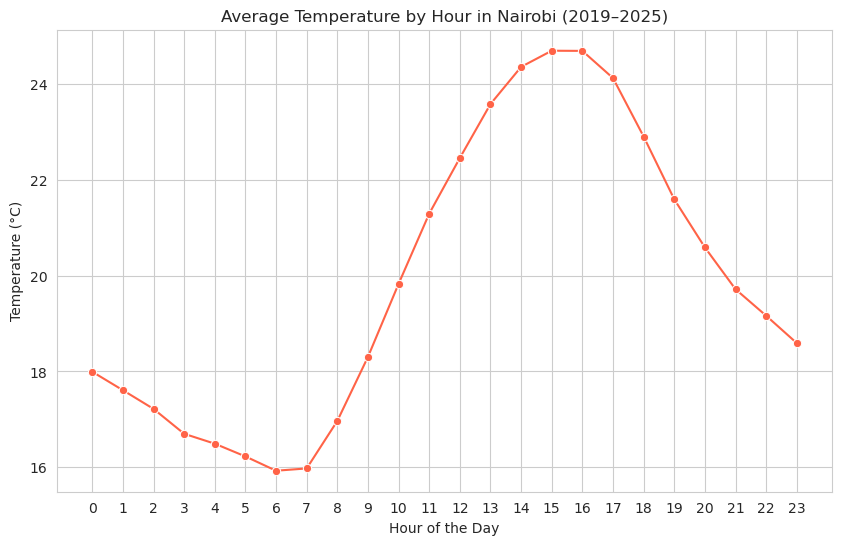

In [125]:
# Line plot: Average temperature by hour
plt.figure()
sns.lineplot(data=hourly_weather, x='hour', y='temp', marker='o', color='#FF6347')
plt.title('Average Temperature by Hour in Nairobi (2019–2025)')
plt.xlabel('Hour of the Day')
plt.ylabel('Temperature (°C)')
plt.xticks(range(0, 24))
plt.show()

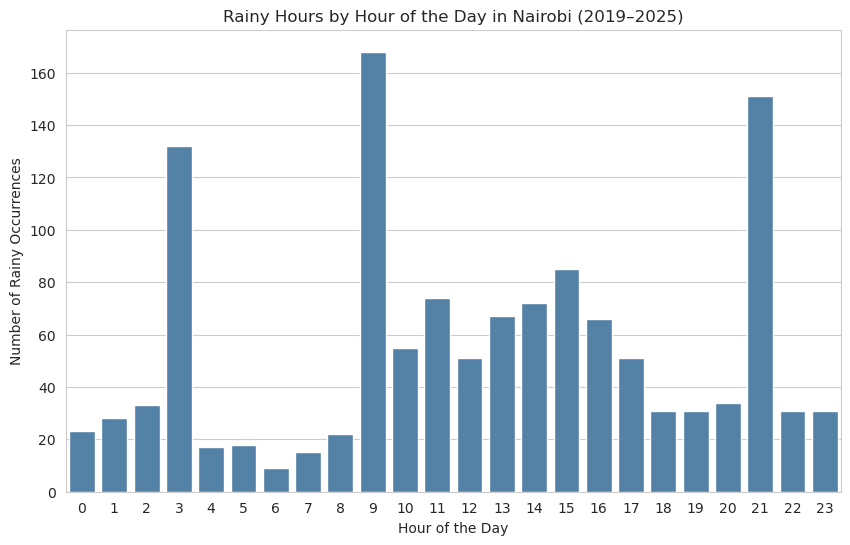

In [126]:
# Bar plot: Rainy hours by hour
plt.figure()
sns.barplot(data=hourly_weather, x='hour', y='rainy_hours', color='#4682B4')
plt.title('Rainy Hours by Hour of the Day in Nairobi (2019–2025)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rainy Occurrences')
plt.xticks(range(0, 24))
plt.show()

### Define Movie Genre Rules
    
We’ll create a model to recommend movie genres based on the hour and weather conditions. The rules consider both time of day (to match viewing habits) and weather (to match mood):
- **Morning (6–11)**: If sunny (`cloudcover` < 50), recommend Comedy/Romance for a light start. If rainy (`precip` > 0), suggest Family/Animation.

- **Afternoon (12–17)**: If warm (`temp` > 20°C), recommend Action/Adventure for energy. If rainy, suggest Mystery/Thriller.

- **Evening/Night (18–23)**: If cool (`temp` < 18°C) or rainy, recommend Drama/Horror for cozy nights. Otherwise, suggest Sci-Fi/Fantasy.

- **Late Night/Early Morning (0–5)**: Recommend Documentary/Indie for calm, reflective hours

    
**What we’ll do:**

- Apply the rules to assign a genre to each hour in the data.

- Summarize genre recommendations by hour.

- Plot the distribution of genres by hour.

In [127]:
# Function to recommend movie genres based on hour and weather
def suggest_genre(row):
    hour = row['hour']
    if 6 <= hour <= 11:  # Morning
        if row['precip'] > 0:
            return 'Family/Animation'
        elif row['cloudcover'] < 50:
            return 'Comedy/Romance'
        else:
            return 'Family/Animation'
    elif 12 <= hour <= 17:  # Afternoon
        if row['precip'] > 0:
            return 'Mystery/Thriller'
        elif row['temp'] > 20:
            return 'Action/Adventure'
        else:
            return 'Mystery/Thriller'
    elif 18 <= hour <= 23:  # Evening/Night
        if row['precip'] > 0 or row['temp'] < 18:
            return 'Drama/Horror'
        else:
            return 'Sci-Fi/Fantasy'
    else:  # Late Night/Early Morning (0–5)
        return 'Documentary/Indie'

In [128]:
# Apply genre recommendations
data['movie_genre'] = data.apply(suggest_genre, axis=1)

In [129]:
 # Summarize genres by hour
genre_by_hour = data.groupby(['hour', 'movie_genre']).size().unstack().fillna(0)

<Figure size 1000x600 with 0 Axes>

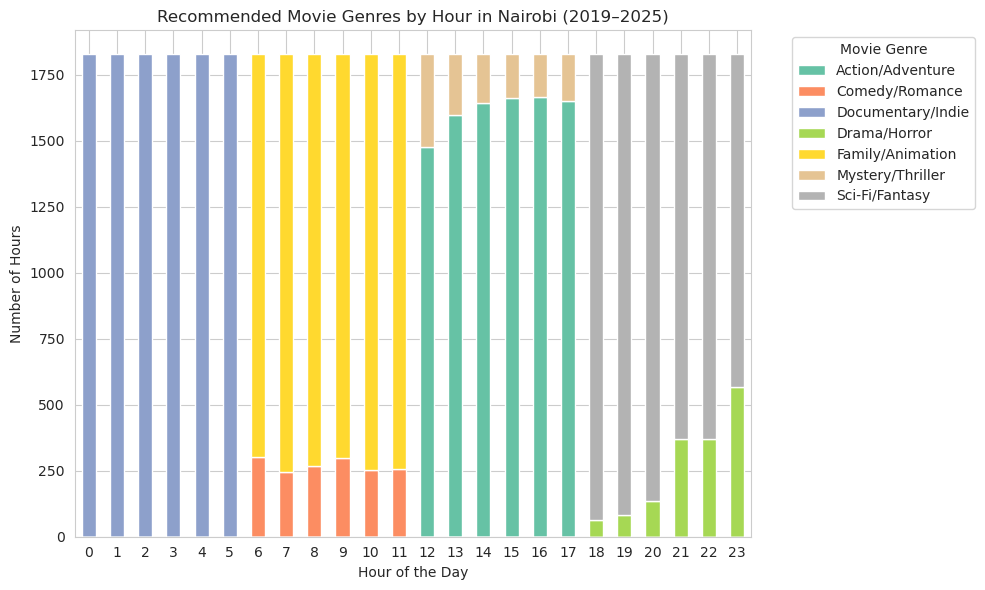

In [130]:
# Plot stacked bar chart
plt.figure()
genre_by_hour.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Recommended Movie Genres by Hour in Nairobi (2019–2025)')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Hours')
plt.xticks(range(0, 24), rotation=0)
plt.legend(title='Movie Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [131]:
# Show genre summary\n",
print('Genre recommendations by hour:')
display(genre_by_hour)

Genre recommendations by hour:


movie_genre,Action/Adventure,Comedy/Romance,Documentary/Indie,Drama/Horror,Family/Animation,Mystery/Thriller,Sci-Fi/Fantasy
hour,,,,,,,
0,0.0,0.0,1827.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1827.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1827.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1827.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1827.0,0.0,0.0,0.0,0.0
5,0.0,0.0,1827.0,0.0,0.0,0.0,0.0
6,0.0,301.0,0.0,0.0,1526.0,0.0,0.0
7,0.0,247.0,0.0,0.0,1580.0,0.0,0.0
8,0.0,268.0,0.0,0.0,1559.0,0.0,0.0
